# PyTorch Uncertainty Estimation

In this lecture we are going to look at the code to demonstrate uncertainty
estimation. Rather than have our network predict a single value `y`, it will
predict a `(mean, log-variance)` pair and be trained to maximize the
log-likelihood of the data under a Gaussian with that mean and variance --
so the network learns not just a best-guess prediction, but how confident it
should be about it.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler

In [2]:
# data will come from a known distribution
# so we can check our answer, duh!
def generate_batch(batch_size=32):
  # x in (-5, +5)
  x = np.random.random(batch_size)*10 - 5

  # sd is a function of x
  sd = 0.05 + 0.1 * (x + 5)

  # target = mean + noise * sd
  y = np.cos(x) - 0.3 * x + np.random.randn(batch_size) * sd

  return x, y

This implements the data generating process: `x` is uniform on `(-5, +5)`,
the true mean is `cos(x) - 0.3x`, and the noise's standard deviation grows
linearly with `x` -- so the data is *heteroscedastic* (noisier in some regions
than others), which is exactly the kind of thing a single-output regression
network can't represent.

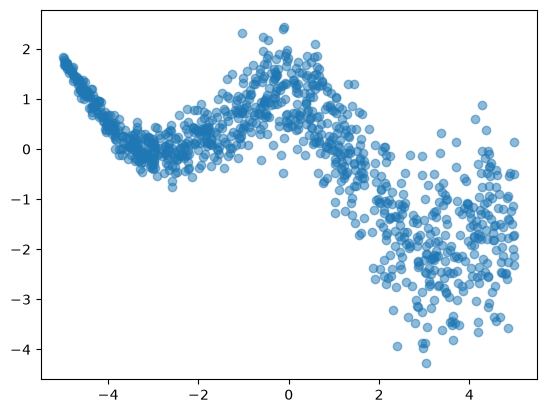

In [3]:
# visualize the data
x, y = generate_batch(1024)
plt.scatter(x, y, alpha=0.5);

Next we instantiate the model and we set the device and move the model to
the GPU next.

In [4]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.ann1 = nn.Sequential(
      nn.Linear(1, 10),
      nn.Tanh(),
      nn.Linear(10, 1),
    )
    self.ann2 = nn.Sequential(
      nn.Linear(1, 10),
      nn.Tanh(),
      nn.Linear(10, 1),
    )

  def forward(self, inputs):
    # returns (mean, log-variance)
    return self.ann1(inputs), self.ann2(inputs)

In [5]:
model = Model()

The course video never moves anything to a GPU (this whole script just runs
on CPU implicitly). Here we add the usual `mps`/`cuda`/`cpu` device selection
and move the model onto it -- since every tensor created below (`inputs`,
`targets`) is also moved to `device`, and predictions are brought back with
`.cpu()` before `.numpy()`, which a GPU tensor doesn't support directly.

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)
model.to(device)

mps


Model(
  (ann1): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
  (ann2): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)

Next we instantiate the model and then we create our custom loss.

In [7]:
def criterion(outputs, targets):
  mu = outputs[0]
  v = torch.exp(outputs[1])

  # coefficient term
  c = torch.log(torch.sqrt(2 * np.pi * v))

  # exponent term
  f = 0.5 / v * (targets - mu)**2

  # mean log-likelihood
  nll = torch.mean(c + f)

  return nll

This is the negative log-likelihood of a Gaussian, decomposed into a
"coefficient term" (the `log(sqrt(2*pi*variance))` normalizing constant) and
an "exponent term" (the squared error, scaled inversely by variance). Lastly
we add the coefficient term and the exponent term together and take the mean.

In [8]:
optimizer = torch.optim.Adam(model.parameters())

So this is nothing really new.

In [9]:
n_epochs = 5000
batch_size = 128
losses = np.zeros(n_epochs)
for i in range(n_epochs):
  x, y = generate_batch(batch_size)

  # conver to torch tensor
  inputs = torch.from_numpy(x).float().to(device)
  targets = torch.from_numpy(y).float().to(device)

  # reshape data
  inputs, targets = inputs.view(-1, 1), targets.view(-1, 1)

  # zero grad
  optimizer.zero_grad()

  # forward pass
  outputs = model(inputs)
  loss = criterion(outputs, targets)

  # store loss
  losses[i] = loss.item()

  # print loss
  if i % 1000 == 0:
    print(i, losses[i])

  # optimize
  loss.backward()
  optimizer.step()

0 1.9897960424423218
1000 0.8953057527542114
2000 0.8165556192398071
3000 0.7106841206550598
4000 0.6598827242851257


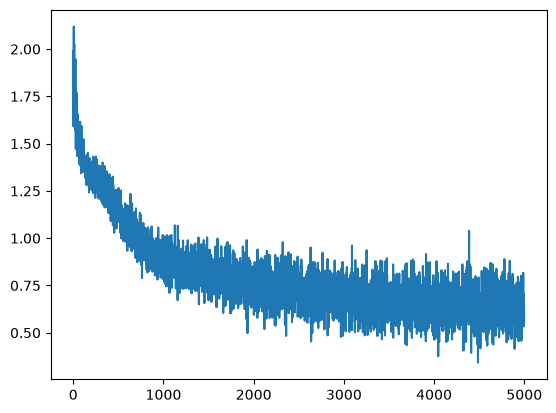

In [10]:
plt.plot(losses);

Now we plot the model predictions -- the mean as a red line, and a shaded
band of `+/- 1` standard deviation around it, and see if it matches what we
know is true.

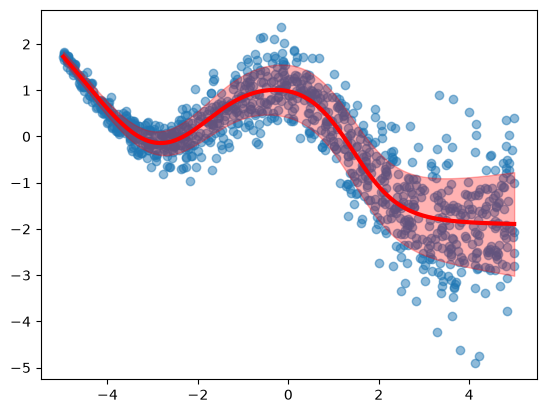

In [11]:
# plot the model predictions
x, y = generate_batch(1024)
plt.scatter(x, y, alpha=0.5)

# conver to torch tensor
inputs = torch.from_numpy(x).float().to(device)
targets = torch.from_numpy(y).float().to(device)

# reshape data
inputs, targets = inputs.view(-1, 1), targets.view(-1, 1)

with torch.no_grad():
  outputs = model(inputs)
  yhat = outputs[0].cpu().numpy().flatten()
  sd = np.exp(outputs[1].cpu().numpy().flatten() / 2) # since encoded variance by default

  idx = np.argsort(x)
  plt.plot(x[idx], yhat[idx], linewidth=3, color='red')
  plt.fill_between(x[idx], yhat[idx] - sd[idx], yhat[idx] + sd[idx], color='red', alpha=0.3)
  plt.show()

So here's the plot, and as you can see the band increases as we go from left
to right, and our model accurately captures the growing uncertainty (`sd`) we
built into `generate_batch` -- it isn't just predicting a mean, it's also
learned, purely from the data, how much to trust that mean at each `x`.